# 路由：条件分支
add_conditional_edges

In [1]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)

{'topic': '猫咪', 'poem': '## 《猫》\n\n它蹑足走过黄昏的瓦檐，\n把影子遗落在\n我摊开的书页间。\n有时是屋顶的云，有时是\n茶凉前的一声呵欠。\n\n你永远数不清它藏起了多少个夜晚，\n像数不清，露水\n在辞行前\n怎样别在草尖。\n直到晨光在毛尖结出铃铛——\n呵，那么多梦的剔透，凉的甜。\n\n它不负责解释这个秋天，\n只把落叶踩出年迈的唱片，\n旋律里鱼骨状的疼痛\n正在腐烂。\n你数着它尾巴上的年轮，\n一节，一节……\n就掉进了柔软的深渊。\n\n暗处，它用瞳孔酿制月亮，\n有时瘦成一枚别针，\n有时滚圆，像药片。\n当它忽然弓起脊背，\n所有逝去的、未至的\n都在那弧度里打了个寒颤——\n\n或许我们该学着，用蜷缩\n修补漏风的夜晚。\n像它盘起的睡姿，用呼噜\n缝合冬天的边缘。\n只是每一次伸懒腰，\n都有新的星群，\n在爪尖旋转。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '有一个笑话是这么说的：  \n\n有一天，猫咪对它的主人说：“主人，我有个问题想问你。”  \n主人很惊讶：“咦，你会说话？你问吧。”  \n猫咪说：“为什么你们人类总爱说‘猫有九条命’？”  \n主人笑着解释：“因为你们猫总是很幸运啊，摔下来都能安然无恙。”  \n\n猫咪点了点头，然后一转身，“咣当”一下从桌上跳了下去。  \n主人吓坏了：“你干嘛？”  \n猫咪从地上爬起来，平静地说：“别担心，我试试能不能把剩下的八条命也省出来，这样我就能活到你把罐头打开的那一天了。”', 'content_type': '笑话'}


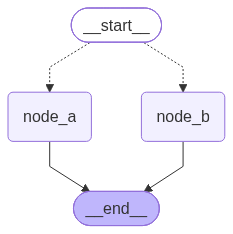

In [2]:
from typing import TypedDict, Literal

from IPython.display import display
from langgraph.graph import StateGraph, START, END


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


# 定义路由
def route(state: OverAllState) -> Literal["node_a", "node_b"]:
    if "诗" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
# builder.add_edge(START, "node_a")
# builder.add_edge(START, "node_b")
builder.add_conditional_edges(START, route)
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(joke_res)

display(graph)